# Run all Evaluations

In [1]:
from pathlib import Path

BASE_DIR = Path("results")

In [2]:
from inference.rewoo_test.main import main as rewoo_main
from inference.direct_prompting_test.main import main as direct_prompting_main
from inference.direct_prompting_tokens_512.main import main as direct_prompting_tokens_512_main
from inference.react.main import main as react_main
import os 
import shutil

if os.path.exists("results"):
    shutil.rmtree("results")

first_n = 100


direct_prompting_main(first_n=first_n)
direct_prompting_tokens_512_main(first_n=first_n)

rewoo_main(first_n=first_n)
react_main(first_n=first_n)

/opt/miniconda3/envs/MA312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MPS (Metal Performance Shaders) is available! Using Apple Silicon GPU.
Limiting to first 100 samples.
✅ ollama/smollm2:135m: Already evaluated all SVAMP test samples. (100/100 samples evaluated)
Limiting to first 100 samples.
✅ ollama/smollm2:135m: Already evaluated all GSM8K test samples. (1319/100 samples evaluated)
Limiting to first 100 samples.
✅ ollama/smollm2:360m: Already evaluated all SVAMP test samples. (300/100 samples evaluated)
Limiting to first 100 samples.
✅ ollama/smollm2:360m: Already evaluated all GSM8K test samples. (1319/100 samples evaluated)
Limiting to first 100 samples.
✅ ollama/qwen2.5:0.5b: Already evaluated all SVAMP test samples. (300/100 samples evaluated)
Limiting to first 100 samples.
✅ ollama/qwen2.5:0.5b: Already evaluated all GSM8K test samples. (1319/100 samples evaluated)
Limiting to first 100 samples.
✅ ollama/qwen3:0.6b: Already evaluated all SVAMP test samples. (300/100 samples evaluated)
Limiting to first 100 samples.
✅ ollama/qwen3:0.6b: Already 

100%|██████████| 100/100 [01:20<00:00,  1.25it/s]


Limiting to first 100 samples.
🚀 ollama/smollm2:135m: Starting evaluation on GSM8K test set.


100%|██████████| 100/100 [02:07<00:00,  1.28s/it]


...

Limiting to first 100 samples.
🚀 ollama/qwen2.5:0.5b: Starting evaluation on GSM8K test set.


100%|██████████| 100/100 [04:59<00:00,  2.99s/it]


Limiting to first 100 samples.
🚀 ollama/qwen3:0.6b: Starting evaluation on SVAMP test set.


 16%|█▌        | 16/100 [01:34<08:17,  5.93s/it]


KeyboardInterrupt: 

# Evaluate Runs

## ReWOO

In [8]:
import pandas as pd
import os


dfs = []
for root, dirs, files in os.walk(BASE_DIR / "rewoo"):
    for file in files:
        fpath = os.path.join(root, file)
        df_r = pd.read_csv(fpath)
        df_r["Method"] = "ReWOO"
        df_r["Model"] = Path(fpath).parent.name + "/" + Path(fpath).stem
        df_r["Dataset"] = Path(fpath).parent.parent.name
        if Path(fpath).parent.parent.name == "SVAMP":
            df_r["target_answer"] = df_r["Equation"] + " = " + df_r["target_answer"].astype(str)
        
        # select columns  Method", "question", "response", "model_history
        df_r = df_r[["Method", "Model", "Dataset", "question", "target_answer", "response", "model_history", "is_correct", "format_correct", "input_tokens", "output_tokens", "total_tokens", "reasoning"]]
        dfs.append(df_r)

df_rewoo = pd.concat(dfs)
df_rewoo.head()

,Method,Model,Dataset,question,target_answer,response,model_history,is_correct,format_correct,input_tokens,output_tokens,total_tokens,reasoning
0,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Winter is almost here and most animals are mig...,( 62.0 - 35.0 ) = 27,-56.0,"[{'plan': {'steps': [['First, calculate how ma...",False,True,318.0,129.0,447.0,"Plan: First, calculate how many bird families ..."
1,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Paige raised 7 goldfish and 12 catfish in the ...,( ( 7.0 + 12.0 ) - 15.0 ) = 4,-5.0,[{'plan': {'steps': [['To find out how many fi...,False,True,291.0,72.0,363.0,"Plan: To find out how many fish disappeared, w..."
2,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Marco and his dad went strawberry picking. Tog...,( ( 22.0 - 36.0 ) + 30.0 ) = 16,-44.0,"[{'plan': {'steps': [[""To find out how much Ma...",False,True,311.0,50.0,361.0,Plan: To find out how much Marco's dad's straw...
3,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Debby bought 200 water bottles and 256 soda bo...,( 256.0 / 4.0 ) = 64,512.0,"[{'plan': {'steps': [['First, calculate how ma...",False,True,303.0,118.0,421.0,"Plan: First, calculate how many water bottles ..."
4,ReWOO,ollama/qwen2.5:0.5b,SVAMP,There were 106 dollars in Olivia's wallet. Aft...,( ( 106.0 - 26.0 ) - 49.0 ) = 31,31.0,[{'plan': {'steps': [['To find out how much Ol...,True,True,303.0,48.0,351.0,Plan: To find out how much Olivia spent at the...


## DP

In [9]:
import pandas as pd
import os

dfs = []
for root, dirs, files in os.walk(BASE_DIR / "dp"):
    for file in files:
        fpath = os.path.join(root, file)
        df_r = pd.read_csv(fpath)
        df_r["Method"] = "Direct Prompting"
        df_r["Model"] = Path(fpath).parent.name + "/" + Path(fpath).stem
        df_r["Dataset"] = Path(fpath).parent.parent.name
        # select columns  Method", "question", "response", "model_history
        df_r = df_r[["Method", "Model", "Dataset", "question", "target_answer", "response", "is_correct", "input_tokens", "output_tokens", "total_tokens", "reasoning"]]
        dfs.append(df_r)

df_dp = pd.concat(dfs)
df_dp.head()

,Method,Model,Dataset,question,target_answer,response,is_correct,input_tokens,output_tokens,total_tokens,reasoning
0,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,Winter is almost here and most animals are mig...,27,To determine how many more bird families flew ...,True,91,509,600,To determine how many more bird families flew ...
1,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,Paige raised 7 goldfish and 12 catfish in the ...,4,"To determine how many fish disappeared, we nee...",True,65,159,224,"To determine how many fish disappeared, we nee..."
2,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,Marco and his dad went strawberry picking. Tog...,16,To determine how much Marco's father's strawbe...,False,84,241,325,To determine how much Marco's father's strawbe...
3,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,Debby bought 200 water bottles and 256 soda bo...,64,To determine how long the soda bottles will la...,False,77,229,306,To determine how long the soda bottles will la...
4,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,There were 106 dollars in Olivia's wallet. Aft...,31,To determine how much Olivia spent at the supe...,True,76,289,365,To determine how much Olivia spent at the supe...


## DP Tokens 512

In [ ]:
import pandas as pd
import os

dfs = []
for root, dirs, files in os.walk(BASE_DIR / "dp-tokens-512"):
    for file in files:
        fpath = os.path.join(root, file)
        df_r = pd.read_csv(fpath)
        df_r["Method"] = "Direct Prompting (512 Tokens)"
        df_r["Model"] = Path(fpath).parent.name + "/" + Path(fpath).stem
        df_r["Dataset"] = Path(fpath).parent.parent.name
        # select columns  Method", "question", "response", "model_history
        df_r = df_r[["Method", "Model", "Dataset", "question", "target_answer", "response", "is_correct", "input_tokens", "output_tokens", "total_tokens", "reasoning"]]
        dfs.append(df_r)

df_dp_512 = pd.concat(dfs)
df_dp_512.head()

## ReAct

In [11]:
dfs = []
for root, dirs, files in os.walk(BASE_DIR / "react"):
    for file in files:
        fpath = os.path.join(root, file)
        df_r = pd.read_csv(fpath)
        df_r["Method"] = "ReAct"
        df_r["Model"] = Path(fpath).parent.name + "/" + Path(fpath).stem
        df_r["Dataset"] = Path(fpath).parent.parent.name
        # select columns  Method", "question", "response", "model_history
        df_r = df_r[["Method", "Model", "Dataset", "question", "target_answer", "response", "is_correct", "input_tokens", "output_tokens", "total_tokens", "reasoning"]]
        dfs.append(df_r)

df_react = pd.concat(dfs)
df_react.head()

,Method,Model,Dataset,question,target_answer,response,is_correct,input_tokens,output_tokens,total_tokens,reasoning
0,ReAct,ollama/qwen2.5:0.5b,SVAMP,Winter is almost here and most animals are mig...,27,There were 56 more bird families that flew awa...,False,503,51,554,NaN
1,ReAct,ollama/qwen2.5:0.5b,SVAMP,Paige raised 7 goldfish and 12 catfish in the ...,4,Paige initially had a total of \(7 + 12 = 19\)...,True,589,253,842,NaN
2,ReAct,ollama/qwen2.5:0.5b,SVAMP,Marco and his dad went strawberry picking. Tog...,16,Marco's dad's strawberries weighed 74 pounds now.,False,488,42,530,NaN
3,ReAct,ollama/qwen2.5:0.5b,SVAMP,Debby bought 200 water bottles and 256 soda bo...,64,Debby's water bottles last her for 568 days. I...,False,472,67,539,NaN
4,ReAct,ollama/qwen2.5:0.5b,SVAMP,There were 106 dollars in Olivia's wallet. Aft...,31,Olivia spent 57 dollars at the supermarket.,False,468,37,505,NaN


## ALL

In [ ]:
df = pd.concat([df_dp, df_dp_512])
df.head()

,Method,Model,Dataset,question,target_answer,response,model_history,is_correct,format_correct,input_tokens,output_tokens,total_tokens,reasoning
0,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Winter is almost here and most animals are mig...,( 62.0 - 35.0 ) = 27,-56.0,"[{'plan': {'steps': [['First, calculate how ma...",False,True,318.0,129.0,447.0,"Plan: First, calculate how many bird families ..."
1,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Paige raised 7 goldfish and 12 catfish in the ...,( ( 7.0 + 12.0 ) - 15.0 ) = 4,-5.0,[{'plan': {'steps': [['To find out how many fi...,False,True,291.0,72.0,363.0,"Plan: To find out how many fish disappeared, w..."
2,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Marco and his dad went strawberry picking. Tog...,( ( 22.0 - 36.0 ) + 30.0 ) = 16,-44.0,"[{'plan': {'steps': [[""To find out how much Ma...",False,True,311.0,50.0,361.0,Plan: To find out how much Marco's dad's straw...
3,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Debby bought 200 water bottles and 256 soda bo...,( 256.0 / 4.0 ) = 64,512.0,"[{'plan': {'steps': [['First, calculate how ma...",False,True,303.0,118.0,421.0,"Plan: First, calculate how many water bottles ..."
4,ReWOO,ollama/qwen2.5:0.5b,SVAMP,There were 106 dollars in Olivia's wallet. Aft...,( ( 106.0 - 26.0 ) - 49.0 ) = 31,31.0,[{'plan': {'steps': [['To find out how much Ol...,True,True,303.0,48.0,351.0,Plan: To find out how much Olivia spent at the...


# Plot 1: Accuracy

In [13]:
# Assume 'grouped' is your DataFrame with columns: Model, Method, Dataset, mean_correct_answers

# If 'grouped' does not have 'Dataset', use the one grouped by ["Dataset", "Model", "Method"]
grouped = df.groupby(["Dataset", "Model", "Method"]).agg(
    mean_correct_answers=("is_correct", "mean")
).reset_index()

# Pivot the table to get the desired format
pivot = grouped.pivot_table(
    index="Model",
    columns=["Dataset", "Method"],
    values="mean_correct_answers"
)

# Optional: Convert to percentage and round
pivot = (pivot * 100).round(0).astype("Int64").astype(str) + "%"

# Reorder columns if needed
pivot = pivot.reindex(
    columns=pd.MultiIndex.from_product(
        [["SVAMP", "GSM8K"], ["Direct Prompting", "ReAct", "ReWOO"]]
    ),
    fill_value=""
)

# Display the table
display(pivot)

SVAMP                          GSM8K         \
                       Direct Prompting  ReAct  ReWOO Direct Prompting  ReAct   
Model                                                                           
ollama/gemma3:1b                    60%  <NA>%  <NA>%              40%  <NA>%   
ollama/llama3.2:1b                  55%  <NA>%  <NA>%              25%  <NA>%   
ollama/qwen2-math:1.5b              90%  <NA>%  <NA>%              65%  <NA>%   
ollama/qwen2.5:0.5b                 45%    25%    25%              20%    15%   
ollama/qwen2.5:1.5b                 80%  <NA>%  <NA>%              45%  <NA>%   
ollama/qwen3:0.6b                   90%    80%    50%              35%    40%   
ollama/qwen3:1.7b                   70%    90%    65%              55%    80%   
ollama/smollm2:1.7b                 75%  <NA>%  <NA>%              20%  <NA>%   
ollama/smollm2:135m                  0%  <NA>%     0%               0%  <NA>%   
ollama/smollm2:360m                 25%  <NA>%     0%              10%  <NA>%   

                               
                        ReWOO  
Model                          
ollama/gemma3:1b        <NA>%  
ollama/llama3.2:1b      <NA>%  
ollama/qwen2-math:1.5b  <NA>%  
ollama/qwen2.5:0.5b       10%  
ollama/qwen2.5:1.5b     <NA>%  
ollama/qwen3:0.6b          0%  
ollama/qwen3:1.7b         20%  
ollama/smollm2:1.7b     <NA>%  
ollama/smollm2:135m        0%  
ollama/smollm2:360m        5%

# Plot 2: Token Usage

## Plot 2a: Mean Token Usage

In [14]:
# Group by Model and Method, and calculate mean tokens
mean_token_usage = df.groupby(["Model", "Method"]).agg(
    mean_correct_answers=("is_correct", "mean"),
    mean_input_tokens=("input_tokens", "mean"),
    mean_output_tokens=("output_tokens", "mean"),
    mean_total_tokens=("total_tokens", "mean"),
)
mean_token_usage

mean_correct_answers  \
Model                  Method                                   
ollama/gemma3:1b       Direct Prompting                 0.500   
ollama/llama3.2:1b     Direct Prompting                 0.400   
ollama/qwen2-math:1.5b Direct Prompting                 0.775   
ollama/qwen2.5:0.5b    Direct Prompting                 0.325   
                       ReAct                            0.200   
                       ReWOO                            0.175   
ollama/qwen2.5:1.5b    Direct Prompting                 0.625   
ollama/qwen3:0.6b      Direct Prompting                 0.625   
                       ReAct                            0.600   
                       ReWOO                            0.250   
ollama/qwen3:1.7b      Direct Prompting                 0.625   
                       ReAct                            0.850   
                       ReWOO                            0.425   
ollama/smollm2:1.7b    Direct Prompting                 0.475   
ollama/smollm2:135m    Direct Prompting                 0.000   
                       ReWOO                            0.000   
ollama/smollm2:360m    Direct Prompting                 0.175   
                       ReWOO                            0.025   

                                         mean_input_tokens  \
Model                  Method                                
ollama/gemma3:1b       Direct Prompting          59.775000   
ollama/llama3.2:1b     Direct Prompting          73.550000   
ollama/qwen2-math:1.5b Direct Prompting          57.125000   
ollama/qwen2.5:0.5b    Direct Prompting          80.125000   
                       ReAct                    487.825000   
                       ReWOO                    307.361111   
ollama/qwen2.5:1.5b    Direct Prompting          80.125000   
ollama/qwen3:0.6b      Direct Prompting          59.125000   
                       ReAct                    246.350000   
                       ReWOO                    272.600000   
ollama/qwen3:1.7b      Direct Prompting          59.125000   
                       ReAct                    691.925000   
                       ReWOO                    276.200000   
ollama/smollm2:1.7b    Direct Prompting          80.475000   
ollama/smollm2:135m    Direct Prompting          81.475000   
                       ReWOO                    307.625000   
ollama/smollm2:360m    Direct Prompting          81.475000   
                       ReWOO                    310.240000   

                                         mean_output_tokens  mean_total_tokens  
Model                  Method                                                   
ollama/gemma3:1b       Direct Prompting          788.950000         848.725000  
ollama/llama3.2:1b     Direct Prompting          121.225000         194.775000  
ollama/qwen2-math:1.5b Direct Prompting          278.500000         335.625000  
ollama/qwen2.5:0.5b    Direct Prompting          276.750000         356.875000  
                       ReAct                     154.050000         641.875000  
                       ReWOO                      99.583333         406.944444  
ollama/qwen2.5:1.5b    Direct Prompting          263.475000         343.600000  
ollama/qwen3:0.6b      Direct Prompting         1320.925000        1380.050000  
                       ReAct                     729.925000         976.275000  
                       ReWOO                     394.666667         667.266667  
ollama/qwen3:1.7b      Direct Prompting         1606.625000        1665.750000  
                       ReAct                     810.325000        1502.250000  
                       ReWOO                     388.100000         664.300000  
ollama/smollm2:1.7b    Direct Prompting          158.675000         239.150000  
ollama/smollm2:135m    Direct Prompting          198.100000         279.575000  
                       ReWOO                     346.541667         654.166667  
ollama/smollm2:360m    Direct Prompting  

## Plot 2b: Mean Token Usage SVAMP

In [15]:
svamp_df = df[df["Dataset"] == "SVAMP"]
token_usage_svamp = svamp_df.groupby(["Model", "Method"]).agg(
    mean_correct_answers=("is_correct", "mean"),
    mean_input_tokens=("input_tokens", "mean"),
    mean_output_tokens=("output_tokens", "mean"),
    mean_total_tokens=("total_tokens", "mean"),
)
token_usage_svamp

mean_correct_answers  \
Model                  Method                                   
ollama/gemma3:1b       Direct Prompting                  0.60   
ollama/llama3.2:1b     Direct Prompting                  0.55   
ollama/qwen2-math:1.5b Direct Prompting                  0.90   
ollama/qwen2.5:0.5b    Direct Prompting                  0.45   
                       ReAct                             0.25   
                       ReWOO                             0.25   
ollama/qwen2.5:1.5b    Direct Prompting                  0.80   
ollama/qwen3:0.6b      Direct Prompting                  0.90   
                       ReAct                             0.80   
                       ReWOO                             0.50   
ollama/qwen3:1.7b      Direct Prompting                  0.70   
                       ReAct                             0.90   
                       ReWOO                             0.65   
ollama/smollm2:1.7b    Direct Prompting                  0.75   
ollama/smollm2:135m    Direct Prompting                  0.00   
                       ReWOO                             0.00   
ollama/smollm2:360m    Direct Prompting                  0.25   
                       ReWOO                             0.00   

                                         mean_input_tokens  \
Model                  Method                                
ollama/gemma3:1b       Direct Prompting          49.450000   
ollama/llama3.2:1b     Direct Prompting          63.150000   
ollama/qwen2-math:1.5b Direct Prompting          46.900000   
ollama/qwen2.5:0.5b    Direct Prompting          69.900000   
                       ReAct                    481.450000   
                       ReWOO                    297.222222   
ollama/qwen2.5:1.5b    Direct Prompting          69.900000   
ollama/qwen3:0.6b      Direct Prompting          48.900000   
                       ReAct                    205.900000   
                       ReWOO                    272.166667   
ollama/qwen3:1.7b      Direct Prompting          48.900000   
                       ReAct                    692.900000   
                       ReWOO                    272.000000   
ollama/smollm2:1.7b    Direct Prompting          70.050000   
ollama/smollm2:135m    Direct Prompting          71.050000   
                       ReWOO                    299.692308   
ollama/smollm2:360m    Direct Prompting          71.050000   
                       ReWOO                    299.200000   

                                         mean_output_tokens  mean_total_tokens  
Model                  Method                                                   
ollama/gemma3:1b       Direct Prompting          790.350000         839.800000  
ollama/llama3.2:1b     Direct Prompting           91.150000         154.300000  
ollama/qwen2-math:1.5b Direct Prompting          195.800000         242.700000  
ollama/qwen2.5:0.5b    Direct Prompting          207.250000         277.150000  
                       ReAct                     103.150000         584.600000  
                       ReWOO                      69.666667         366.888889  
ollama/qwen2.5:1.5b    Direct Prompting          175.950000         245.850000  
ollama/qwen3:0.6b      Direct Prompting          995.500000        1044.400000  
                       ReAct                     421.250000         627.150000  
                       ReWOO                     374.750000         646.916667  
ollama/qwen3:1.7b      Direct Prompting         1390.900000        1439.800000  
                       ReAct                     577.550000        1270.450000  
                       ReWOO                     376.266667         648.266667  
ollama/smollm2:1.7b    Direct Prompting           89.750000         159.800000  
ollama/smollm2:135m    Direct Prompting          128.750000         199.800000  
                       ReWOO                     398.846154         698.538462  
ollama/smollm2:360m    Direct Prompting  

## Plot 2c: Mean Token Usage GSM8K

In [16]:
gsm8k_df = df[df["Dataset"] == "GSM8K"]
token_usage_gsm8K = gsm8k_df.groupby(["Model", "Method"]).agg(
    mean_correct_answers=("is_correct", "mean"),
    mean_input_tokens=("input_tokens", "mean"),
    mean_output_tokens=("output_tokens", "mean"),
    mean_total_tokens=("total_tokens", "mean"),
)
token_usage_gsm8K

mean_correct_answers  \
Model                  Method                                   
ollama/gemma3:1b       Direct Prompting                  0.40   
ollama/llama3.2:1b     Direct Prompting                  0.25   
ollama/qwen2-math:1.5b Direct Prompting                  0.65   
ollama/qwen2.5:0.5b    Direct Prompting                  0.20   
                       ReAct                             0.15   
                       ReWOO                             0.10   
ollama/qwen2.5:1.5b    Direct Prompting                  0.45   
ollama/qwen3:0.6b      Direct Prompting                  0.35   
                       ReAct                             0.40   
                       ReWOO                             0.00   
ollama/qwen3:1.7b      Direct Prompting                  0.55   
                       ReAct                             0.80   
                       ReWOO                             0.20   
ollama/smollm2:1.7b    Direct Prompting                  0.20   
ollama/smollm2:135m    Direct Prompting                  0.00   
                       ReWOO                             0.00   
ollama/smollm2:360m    Direct Prompting                  0.10   
                       ReWOO                             0.05   

                                         mean_input_tokens  \
Model                  Method                                
ollama/gemma3:1b       Direct Prompting          70.100000   
ollama/llama3.2:1b     Direct Prompting          83.950000   
ollama/qwen2-math:1.5b Direct Prompting          67.350000   
ollama/qwen2.5:0.5b    Direct Prompting          90.350000   
                       ReAct                    494.200000   
                       ReWOO                    317.500000   
ollama/qwen2.5:1.5b    Direct Prompting          90.350000   
ollama/qwen3:0.6b      Direct Prompting          69.350000   
                       ReAct                    286.800000   
                       ReWOO                    274.333333   
ollama/qwen3:1.7b      Direct Prompting          69.350000   
                       ReAct                    690.950000   
                       ReWOO                    288.800000   
ollama/smollm2:1.7b    Direct Prompting          90.900000   
ollama/smollm2:135m    Direct Prompting          91.900000   
                       ReWOO                    317.000000   
ollama/smollm2:360m    Direct Prompting          91.900000   
                       ReWOO                    326.800000   

                                         mean_output_tokens  mean_total_tokens  
Model                  Method                                                   
ollama/gemma3:1b       Direct Prompting          787.550000         857.650000  
ollama/llama3.2:1b     Direct Prompting          151.300000         235.250000  
ollama/qwen2-math:1.5b Direct Prompting          361.200000         428.550000  
ollama/qwen2.5:0.5b    Direct Prompting          346.250000         436.600000  
                       ReAct                     204.950000         699.150000  
                       ReWOO                     129.500000         447.000000  
ollama/qwen2.5:1.5b    Direct Prompting          351.000000         441.350000  
ollama/qwen3:0.6b      Direct Prompting         1646.350000        1715.700000  
                       ReAct                    1038.600000        1325.400000  
                       ReWOO                     474.333333         748.666667  
ollama/qwen3:1.7b      Direct Prompting         1822.350000        1891.700000  
                       ReAct                    1043.100000        1734.050000  
                       ReWOO                     423.600000         712.400000  
ollama/smollm2:1.7b    Direct Prompting          227.600000         318.500000  
ollama/smollm2:135m    Direct Prompting          267.450000         359.350000  
                       ReWOO                     284.727273         601.727273  
ollama/smollm2:360m    Direct Prompting  

In [17]:
# Create melted DataFrame for token usage visualization
import pandas as pd

# Add dataset labels to each DataFrame
mean_token_usage_labeled = mean_token_usage.copy()
mean_token_usage_labeled['Dataset'] = 'ALL'

token_usage_svamp_labeled = token_usage_svamp.copy()
token_usage_svamp_labeled['Dataset'] = 'SVAMP'

token_usage_gsm8K_labeled = token_usage_gsm8K.copy()
token_usage_gsm8K_labeled['Dataset'] = 'GSM8K'

# Combine all token usage DataFrames
combined_token_usage = pd.concat([
    mean_token_usage_labeled,
    token_usage_svamp_labeled, 
    token_usage_gsm8K_labeled
]).reset_index()

# Melt the DataFrame to long format for plotting
melted = combined_token_usage.melt(
    id_vars=['Model', 'Method', 'Dataset'],
    value_vars=['mean_input_tokens', 'mean_output_tokens', 'mean_total_tokens'],
    var_name='TokenType',
    value_name='MeanTokens'
)

print("Melted DataFrame structure:")
print(melted.head())
print(f"\nShape: {melted.shape}")
print(f"Unique TokenTypes: {melted['TokenType'].unique()}")
print(f"Unique Datasets: {melted['Dataset'].unique()}")

Melted DataFrame structure:
                    Model            Method Dataset          TokenType  \
0        ollama/gemma3:1b  Direct Prompting     ALL  mean_input_tokens   
1      ollama/llama3.2:1b  Direct Prompting     ALL  mean_input_tokens   
2  ollama/qwen2-math:1.5b  Direct Prompting     ALL  mean_input_tokens   
3     ollama/qwen2.5:0.5b  Direct Prompting     ALL  mean_input_tokens   
4     ollama/qwen2.5:0.5b             ReAct     ALL  mean_input_tokens   

   MeanTokens  
0      59.775  
1      73.550  
2      57.125  
3      80.125  
4     487.825  

Shape: (162, 5)
Unique TokenTypes: ['mean_input_tokens' 'mean_output_tokens' 'mean_total_tokens']
Unique Datasets: ['ALL' 'SVAMP' 'GSM8K']


## Plot 2d: All together

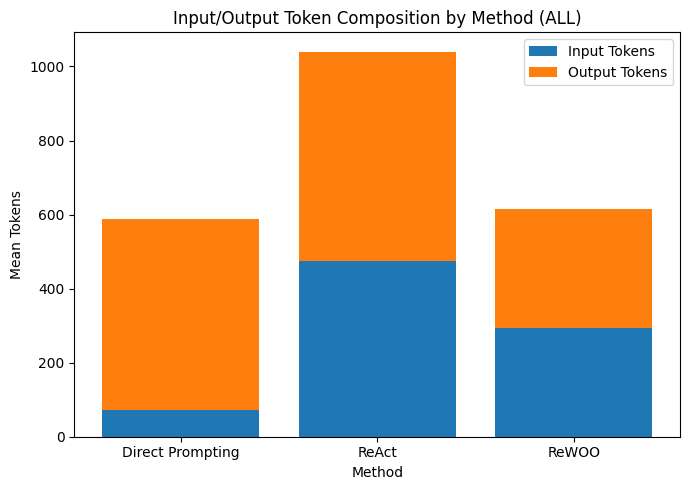

In [18]:
# Stacked barplot: input and output tokens composition by Method (ALL datasets aggregated)
import matplotlib.pyplot as plt

# Filter for ALL dataset and only input/output tokens
agg_data = melted[(melted['Dataset'] == 'ALL') & (melted['TokenType'].isin(['mean_input_tokens', 'mean_output_tokens']))].copy()

# Aggregate by Method
agg_pivot = agg_data.pivot_table(
    index='Method',
    columns='TokenType',
    values='MeanTokens',
    aggfunc='mean'
).reset_index()

plt.figure(figsize=(7, 5))
plt.bar(agg_pivot['Method'], agg_pivot['mean_input_tokens'], label='Input Tokens')
plt.bar(agg_pivot['Method'], agg_pivot['mean_output_tokens'],
        bottom=agg_pivot['mean_input_tokens'], label='Output Tokens')
plt.title('Input/Output Token Composition by Method (ALL)')
plt.ylabel('Mean Tokens')
plt.xlabel('Method')
plt.legend()
plt.tight_layout()

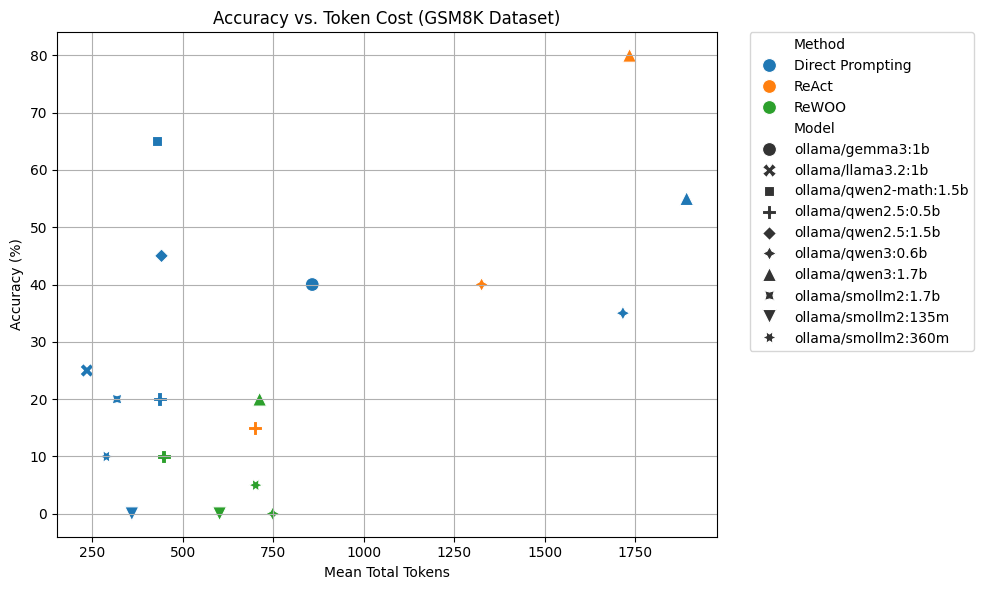

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean accuracy and mean total tokens per Model & Method (aggregated across datasets or select one dataset)
summary = df.groupby(["Dataset", "Model", "Method"]).agg(
    mean_accuracy=("is_correct", "mean"),
    mean_total_tokens=("total_tokens", "mean")
).reset_index()

summary["mean_accuracy"] *= 100  # convert to %

# Example: Plot for GSM8K dataset
gsm8k = summary[summary["Dataset"] == "GSM8K"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=gsm8k, x="mean_total_tokens", y="mean_accuracy", hue="Method", style="Model", s=100)

plt.title("Accuracy vs. Token Cost (GSM8K Dataset)")
plt.xlabel("Mean Total Tokens")
plt.ylabel("Accuracy (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3: Token Usage per Is-Correct

In [20]:
# Table: Mean output tokens aggregated by Method and is_correct (ALL datasets)
agg_output = df.groupby(['Method', 'is_correct'])['output_tokens'].mean().unstack()
agg_output = agg_output.round(1)
agg_output.columns = ['Incorrect', 'Correct'] if 0 in agg_output.columns else agg_output.columns
display(agg_output)

is_correct,False,True
Method,,
Direct Prompting,549.1,479.1
ReAct,586.3,547.2
ReWOO,282.1,311.7


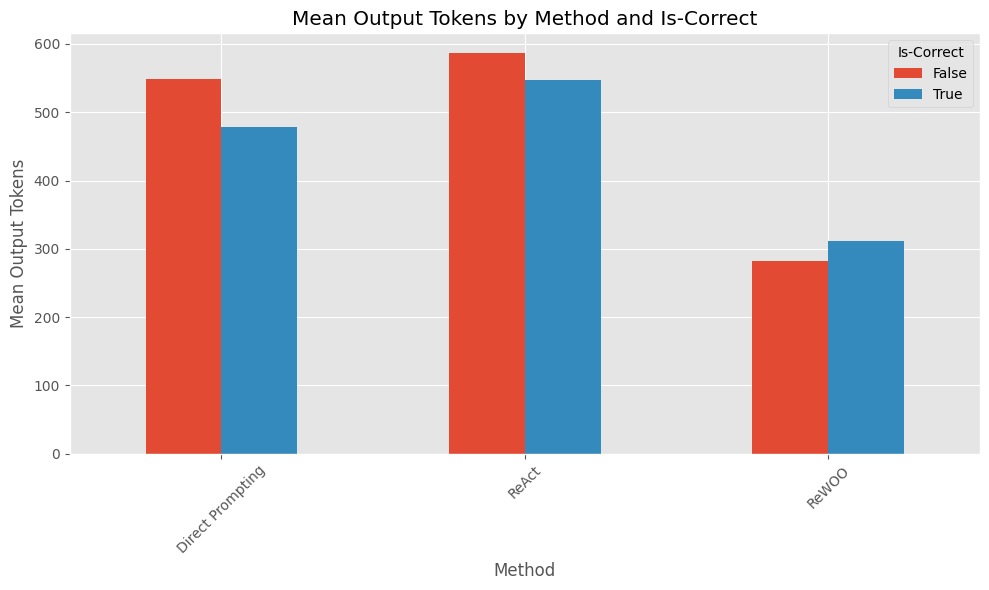

In [22]:
# plot agg_output as barplot
agg_output.plot(kind='bar', figsize=(10, 6))
plt.title('Mean Output Tokens by Method and Is-Correct')
plt.xlabel('Method')
plt.ylabel('Mean Output Tokens')
plt.xticks(rotation=45)
plt.legend(title='Is-Correct')
plt.tight_layout()
plt.show()

In [23]:
import re

def has_wrong_calculation(reasoning_text):
    """
    Detect if reasoning text contains wrongly calculated equations.
    Returns True if wrong calculations are found, False otherwise.
    
    Args:
        reasoning_text (str): The reasoning text to analyze
    
    Returns:
        bool: True if wrong calculations detected, False otherwise
    """
    if not isinstance(reasoning_text, str):
        return False
    
    # Pattern to match equations like "1+1=3", "5*2=11", "10-3=6", "8/2=3"
    equation_pattern = r'(\d+(?:\.\d+)?)\s*([+\-*/])\s*(\d+(?:\.\d+)?)\s*=\s*(\d+(?:\.\d+)?)'
    
    equations = re.findall(equation_pattern, reasoning_text)
    
    for equation in equations:
        num1, operator, num2, result = equation
        num1, num2, result = float(num1), float(num2), float(result)
        
        # Calculate the correct result
        if operator == '+':
            correct_result = num1 + num2
        elif operator == '-':
            correct_result = num1 - num2
        elif operator == '*':
            correct_result = num1 * num2
        elif operator == '/':
            if num2 == 0:
                continue  # Skip division by zero
            correct_result = num1 / num2
        else:
            continue
        
        # Check if the stated result is wrong (with small tolerance for floating point)
        if abs(correct_result - result) > 1e-6:
            return True
    
    return False

# Test the function
test_cases = [
    "1+1=3 and 1+1=2",  # Wrong
    "1+1=2 and 1+1=2",  # Correct
    "5*2=10 and 5*1=6", # Wrong
    "5*2=10", # Correct
    "10-3=6", # Wrong
    "10-3=7", # Correct
    "8/2=3",  # Wrong
    "8/2=4",  # Correct
    "The answer is 5+3=8 which is correct",  # Correct
    "We calculate 2+2=5 so the total is 5",  # Wrong
    "No equations here"  # No equations
]

print("Testing wrong calculation detection:")
for test in test_cases:
    result = has_wrong_calculation(test)
    print(f"'{test}' -> {result}")

Testing wrong calculation detection:
'1+1=3 and 1+1=2' -> True
'1+1=2 and 1+1=2' -> False
'5*2=10 and 5*1=6' -> True
'5*2=10' -> False
'10-3=6' -> True
'10-3=7' -> False
'8/2=3' -> True
'8/2=4' -> False
'The answer is 5+3=8 which is correct' -> False
'We calculate 2+2=5 so the total is 5' -> True
'No equations here' -> False


In [24]:
# Apply wrong calculation detection to the dataset
df_t = df_dp.copy()
df_t['has_wrong_calc'] = df_t['reasoning'].apply(has_wrong_calculation)

In [25]:
# Show summary by model
wrong_calc_summary = df_t.groupby(["Model", 'has_wrong_calc']).size().unstack(fill_value=0)
wrong_calc_summary['total'] = wrong_calc_summary.sum(axis=1)
wrong_calc_summary['wrong_calc_rate'] = (wrong_calc_summary[True] / wrong_calc_summary['total'] * 100).round(2)

print("Wrong Calculation Detection Summary:")
wrong_calc_summary

Wrong Calculation Detection Summary:


has_wrong_calc,False,True,total,wrong_calc_rate
Model,,,,
ollama/gemma3:1b,26,14,40,35.0
ollama/llama3.2:1b,37,3,40,7.5
ollama/qwen2-math:1.5b,37,3,40,7.5
ollama/qwen2.5:0.5b,34,6,40,15.0
ollama/qwen2.5:1.5b,36,4,40,10.0
ollama/qwen3:0.6b,29,11,40,27.5
ollama/qwen3:1.7b,25,15,40,37.5
ollama/smollm2:1.7b,38,2,40,5.0
ollama/smollm2:135m,24,16,40,40.0


In [41]:
# Add column for wrong calculation leading to correct result
df_t['wrong_calc_correct_result'] = df_t['has_wrong_calc'] & df_t['is_correct']

# Enhanced summary by model
enhanced_summary = df_t.groupby(["Model"]).agg({
    'has_wrong_calc': 'sum',
    'is_correct': 'sum', 
    'wrong_calc_correct_result': 'sum'
}).assign(
    total=lambda x: len(df_t.groupby("Model").size()),
    wrong_calc_rate=lambda x: (x['has_wrong_calc'] / len(df_t.groupby("Model").size().iloc[0:len(x)]) * 100).round(2),
    correct_rate=lambda x: (x['is_correct'] / len(df_t.groupby("Model").size().iloc[0:len(x)]) * 100).round(2),
    wrong_calc_but_correct_rate=lambda x: (x['wrong_calc_correct_result'] / x['has_wrong_calc'] * 100).fillna(0).round(2)
)

# Reset the total calculation properly
model_counts = df_t.groupby("Model").size()
enhanced_summary['total'] = enhanced_summary.index.map(model_counts)
enhanced_summary['wrong_calc_rate'] = (enhanced_summary['has_wrong_calc'] / enhanced_summary['total'] * 100).round(2)
enhanced_summary['correct_rate'] = (enhanced_summary['is_correct'] / enhanced_summary['total'] * 100).round(2)
enhanced_summary['wrong_calc_but_correct_rate'] = (enhanced_summary['wrong_calc_correct_result'] / enhanced_summary['has_wrong_calc'] * 100).fillna(0).round(2)

print("Enhanced Wrong Calculation Analysis:")
enhanced_summary[['total', 'has_wrong_calc', 'wrong_calc_rate', 'is_correct', 'correct_rate', 'wrong_calc_correct_result', 'wrong_calc_but_correct_rate']]

Enhanced Wrong Calculation Analysis:


,total,has_wrong_calc,wrong_calc_rate,is_correct,correct_rate,wrong_calc_correct_result,wrong_calc_but_correct_rate
Model,,,,,,,
ollama/qwen2.5:0.5b,200,20,10.0,94,47.0,10,50.00
ollama/qwen3:0.6b,200,15,7.5,66,33.0,5,33.33
ollama/qwen3:1.7b,200,12,6.0,65,32.5,3,25.00
ollama/smollm2:135m,200,79,39.5,4,2.0,3,3.80
ollama/smollm2:360m,200,35,17.5,30,15.0,1,2.86


In [45]:
# Show examples of wrong calculations that led to correct results
print("Examples of WRONG calculations that led to CORRECT final results:")
wrong_calc_correct_examples = df_t[df_t['wrong_calc_correct_result'] == True][['Model', 'reasoning', 'is_correct', 'target_answer']].head(3)
if len(wrong_calc_correct_examples) > 0:
    for idx, row in wrong_calc_correct_examples.iterrows():
        print(f"\nModel: {row['Model']}")
        print(f"Final Result Correct: {row['is_correct']}")
        print(f"Target Answer: {row['target_answer']}")
        print(f"Reasoning: {row['reasoning']}...")
        print("-" * 80)
else:
    print("No examples found where wrong calculations led to correct results.")

print("\n" + "="*80)
print("Examples of WRONG calculations that led to INCORRECT final results:")
wrong_calc_incorrect_examples = df_t[(df_t['has_wrong_calc'] == True) & (df_t['is_correct'] == False)][['Model', 'reasoning', 'is_correct', 'target_answer']].head(3)
if len(wrong_calc_incorrect_examples) > 0:
    for idx, row in wrong_calc_incorrect_examples.iterrows():
        print(f"\nModel: {row['Model']}")
        print(f"Final Result Correct: {row['is_correct']}")
        print(f"Target Answer: {row['target_answer']}")
        print(f"Reasoning: {row['reasoning']}...")
        print("-" * 80)
else:
    print("No examples found where wrong calculations led to incorrect results.")

Examples of WRONG calculations that led to CORRECT final results:

Model: ollama/qwen2.5:0.5b
Final Result Correct: True
Target Answer: 39
Reasoning: To determine how many children were initially riding on the bus, we can follow these steps:

1. Let \( x \) be the number of children initially riding on the bus.
2. At the bus stop, 2 more children got on the bus, so the total number of children became \( x + 2 \).
3. According to the problem, after the bus stop, there were 41 children altogether on the bus.

We can set up the following equation based on this information:
\[ x + 2 = 41 \]

To find \( x \), we need to isolate it on one side of the equation. We do this by subtracting 2 from both sides of the equation:
\[ x + 2 - 2 = 41 - 2 \]
\[ x = 39 \]

Therefore, the number of children initially riding on the bus is \(\boxed{39}\)....
--------------------------------------------------------------------------------

Model: ollama/qwen2.5:0.5b
Final Result Correct: True
Target Answer: 1


# SFT

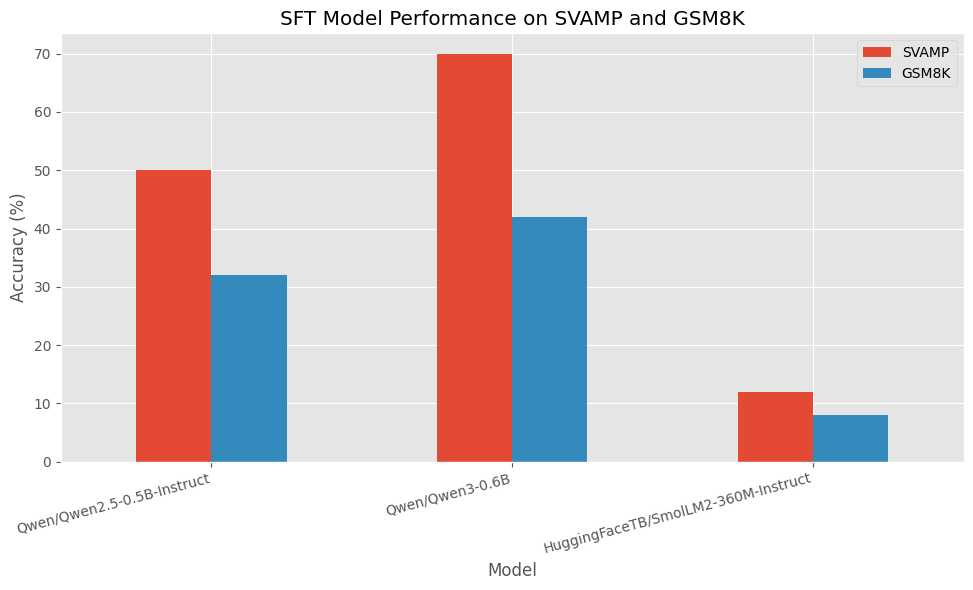

In [ ]:
records = [
    # {
    #     "Model": "Qwen/Qwen2.5-0.5B-Instruct",
    #     "SFT": False,
    #     "SVAMP": 0.33,
    #     "GSM8K": 0.15
    # },
    {
        "Model": "Qwen/Qwen2.5-0.5B-Instruct",
        "Method": "ReWOO",
        "SFT": True,
        "SVAMP": 50.0,
        "GSM8K": 32.0
    },
    # {
    #     "Model": "Qwen/Qwen3-0.6B",
    #     "SFT": False,
    #     "SVAMP": 6.0,
    #     "GSM8K": 2.0
    # },
    {
        "Model": "Qwen/Qwen3-0.6B",
        "Method": "ReWOO",
        "SFT": True,
        "SVAMP": 70.0,
        "GSM8K": 42.0
    },
    # {
    #     "Model": "Qwen/Qwen3-0.6B",
    #     "Method": "DP",
    #     "SFT": True,
    #     "SVAMP": 72.0,
    #     "GSM8K": 42.0
    # },
    {
        "Model": "HuggingFaceTB/SmolLM2-360M-Instruct",
        "Method": "ReWOO",
        "SFT": True,
        "SVAMP": 12.0,
        "GSM8K": 8.0
    },
]

df_sft = pd.DataFrame(records)
# plotbarplot for SFT
import matplotlib.pyplot as plt

# Set plot style
plt.style.use("ggplot")

# Create the bar plot
fig, ax = plt.subplots(figsize=(10, 6))
df_sft.set_index("Model")[["SVAMP", "GSM8K"]].plot(kind="bar", ax=ax)

# Customize plot
ax.set_ylabel("Accuracy (%)")
ax.set_title("SFT Model Performance on SVAMP and GSM8K")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
# Show the plot
plt.show()